In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv(
    "C:\\Users\\aksha\\Downloads\\OnlineRetail.csv",
    encoding="latin1"
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(5268)

In [8]:
df = df.dropna(subset=["CustomerID"])

In [9]:
df.shape

(406829, 8)

In [10]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [11]:
df = df[df["Quantity"] > 0]

In [12]:
df = df[df["UnitPrice"] > 0]

In [13]:
df.shape

(397884, 8)

In [14]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [15]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [16]:
df["Revenue"].sum()

np.float64(8911407.904)

In [17]:
df["CustomerID"].nunique()

4338

In [18]:
df["Country"].value_counts().head(10)

Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1462
Australia           1182
Name: count, dtype: int64

In [19]:
df.shape
df["CustomerID"].nunique()
df["Revenue"].sum()

np.float64(8911407.904)

In [20]:
print("Shape:", df.shape)
print("Unique Customers:", df["CustomerID"].nunique())
print("Total Revenue:", round(df["Revenue"].sum(), 2))

Shape: (397884, 9)
Unique Customers: 4338
Total Revenue: 8911407.9


In [21]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [22]:
df["InvoiceDate"].head()

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]

In [23]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [24]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [25]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


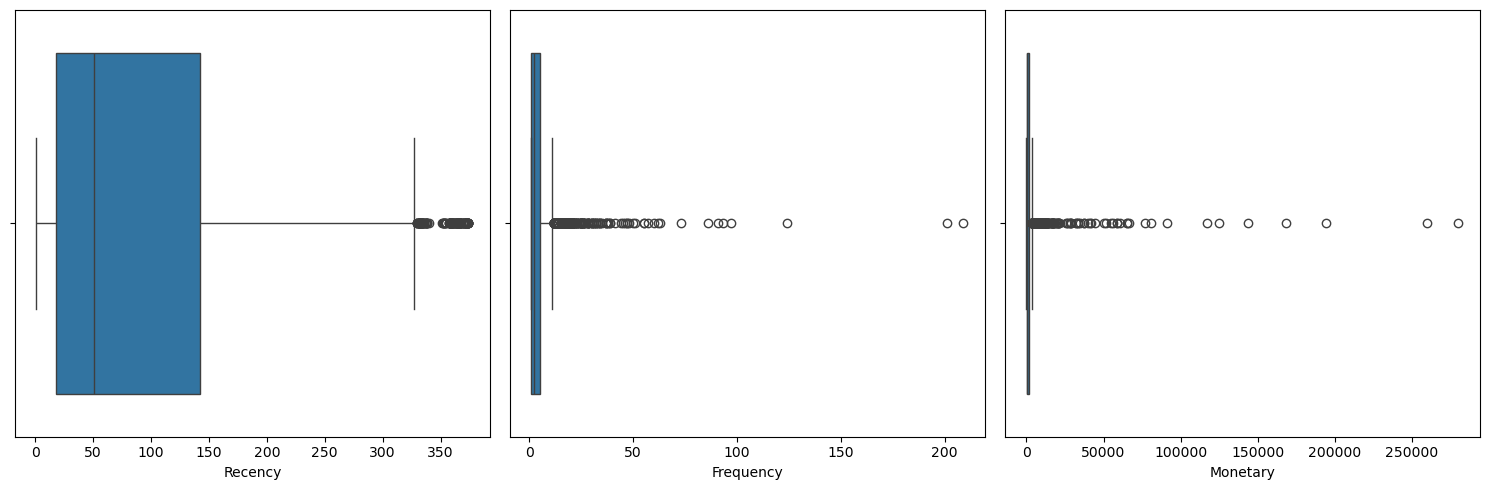

In [26]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(x=rfm["Recency"])

plt.subplot(1,3,2)
sns.boxplot(x=rfm["Frequency"])

plt.subplot(1,3,3)
sns.boxplot(x=rfm["Monetary"])

plt.tight_layout()
plt.show()

In [28]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[column] >= lower) & (df[column] <= upper)]

In [29]:
rfm_clean = rfm.copy()

for col in ["Recency", "Frequency", "Monetary"]:
    rfm_clean = remove_outliers(rfm_clean, col)

rfm_clean.shape

(3602, 3)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    rfm_clean[["Recency", "Frequency", "Monetary"]]
)

In [31]:
scaled_data[:5]

array([[-0.18584038,  0.61569211,  1.40329352],
       [-0.81171665, -0.8300204 ,  1.34669037],
       [ 2.44060472, -0.8300204 , -0.68290842],
       [-0.6217185 ,  2.5433088 ,  2.4141354 ],
       [ 1.25591034, -0.8300204 , -1.03288104]])

In [32]:
inertia = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    inertia.append(kmeans.inertia_)

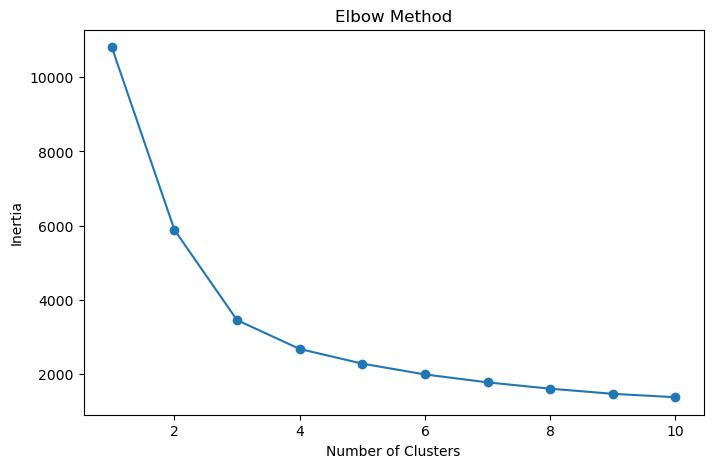

In [33]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [34]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm_clean["Cluster"] = kmeans.fit_predict(scaled_data)

rfm_clean.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,1
12350.0,310,1,334.40,2
12352.0,36,8,2506.04,0
12353.0,204,1,89.00,2


In [35]:
rfm_clean["Cluster"].value_counts()

Cluster
1    1876
2     906
0     820
Name: count, dtype: int64

In [36]:
cluster_summary = rfm_clean.groupby("Cluster").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean"
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,37.14,5.68,1847.40
1,49.61,2.03,558.53
2,227.94,1.49,404.72


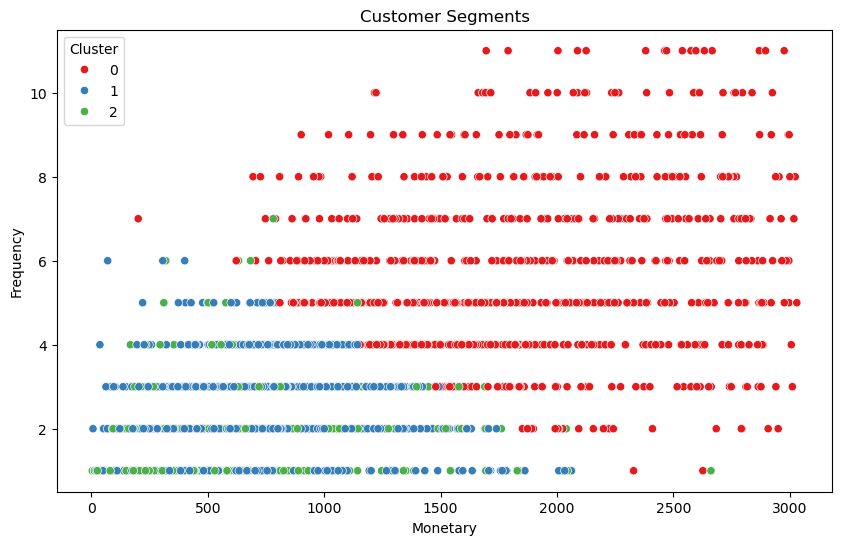

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm_clean,
    x="Monetary",
    y="Frequency",
    hue="Cluster",
    palette="Set1"
)

plt.title("Customer Segments")
plt.show()

In [38]:
rfm_clean.to_csv(
    "customer_segments.csv",
    index=False
)

In [41]:
cluster_summary = rfm_clean.groupby("Cluster").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean"
}).round(2)

print(cluster_summary)

         Recency  Frequency  Monetary
Cluster                              
0          37.14       5.68   1847.40
1          49.61       2.03    558.53
2         227.94       1.49    404.72


In [42]:
segment_map = {
    0: "High Value Customers",
    1: "Regular Customers",
    2: "At-Risk Customers"
}

rfm_clean["Segment"] = rfm_clean["Cluster"].map(segment_map)

rfm_clean.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12348.0,75,4,1797.24,0,High Value Customers
12349.0,19,1,1757.55,1,Regular Customers
12350.0,310,1,334.40,2,At-Risk Customers
12352.0,36,8,2506.04,0,High Value Customers
12353.0,204,1,89.00,2,At-Risk Customers


In [43]:
rfm_clean.to_csv(
    "customer_segments.csv",
    index=False
)

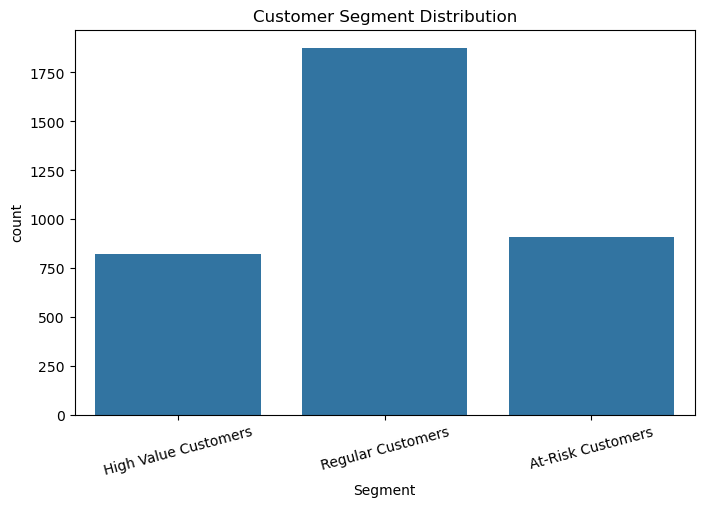

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm_clean,
    x="Segment"
)

plt.title("Customer Segment Distribution")
plt.xticks(rotation=15)
plt.show()

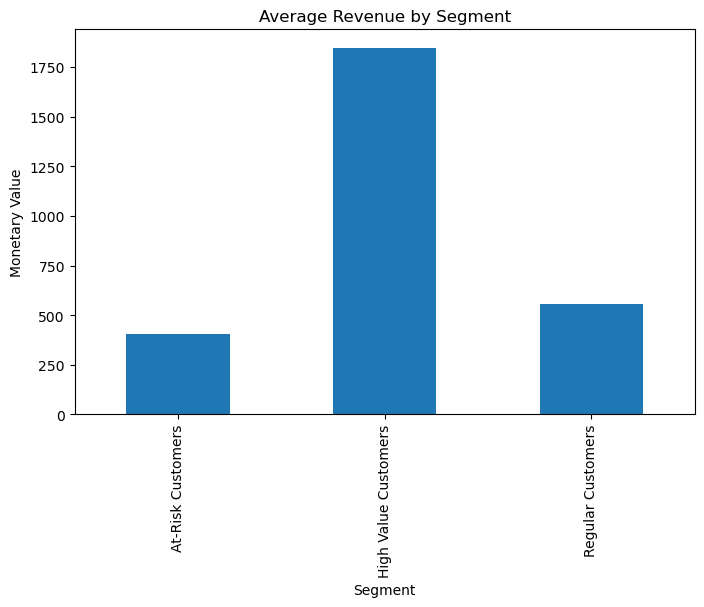

In [45]:
segment_revenue = rfm_clean.groupby("Segment")["Monetary"].mean()

segment_revenue.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Revenue by Segment")
plt.ylabel("Monetary Value")
plt.show()

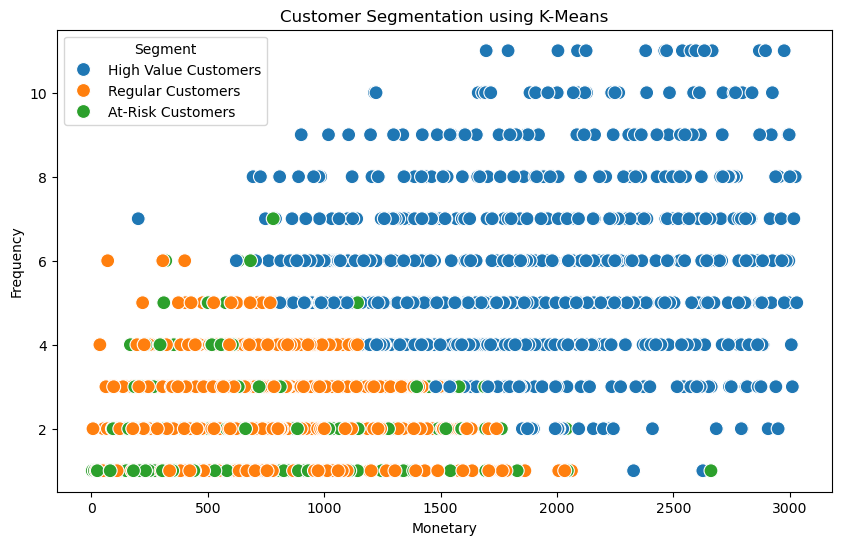

In [46]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm_clean,
    x="Monetary",
    y="Frequency",
    hue="Segment",
    s=100
)

plt.title("Customer Segmentation using K-Means")
plt.show()